<a href="https://colab.research.google.com/github/Sathish120804/NOVEL_ML_BASED_HEALTHCARE_SYSTEM_FOR_QUADRIPLEGIA_PATIENTS/blob/main/RANDOMFOREST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (52957, 7)

K-FOLD MEAN ACC: 0.9807013435407628
K-FOLD STD: 0.0016280351464436143

ACCURACY: 0.9822507552870091

CLASSIFICATION REPORT:

                             precision    recall  f1-score   support

              DOWN-RESTROOM       0.94      0.96      0.95      1250
                  LEFT-FOOD       1.00      1.00      1.00      4181
                       NONE       0.98      0.97      0.98      4309
RIGHT-ELECTRONIC ASSISTANCE       0.99      1.00      0.99      2000
               UP-EMERGENCY       0.96      0.97      0.96      1500

                   accuracy                           0.98     13240
                  macro avg       0.97      0.98      0.98     13240
               weighted avg       0.98      0.98      0.98     13240



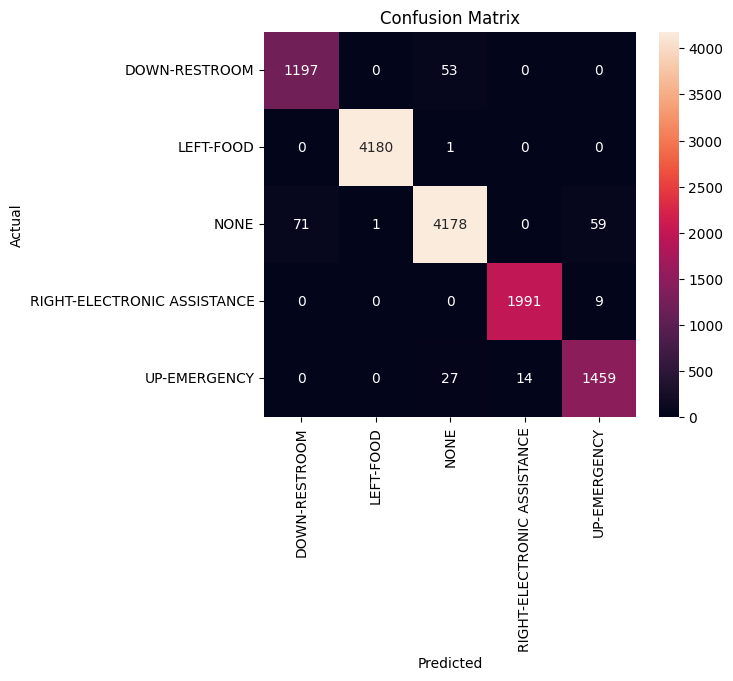


SENSITIVITY & SPECIFICITY:

DOWN-RESTROOM:
  Sensitivity: 0.958
  Specificity: 0.994
LEFT-FOOD:
  Sensitivity: 1.0
  Specificity: 1.0
NONE:
  Sensitivity: 0.97
  Specificity: 0.991
RIGHT-ELECTRONIC ASSISTANCE:
  Sensitivity: 0.996
  Specificity: 0.999
UP-EMERGENCY:
  Sensitivity: 0.973
  Specificity: 0.994

ROC AUC: 0.9984064669294389


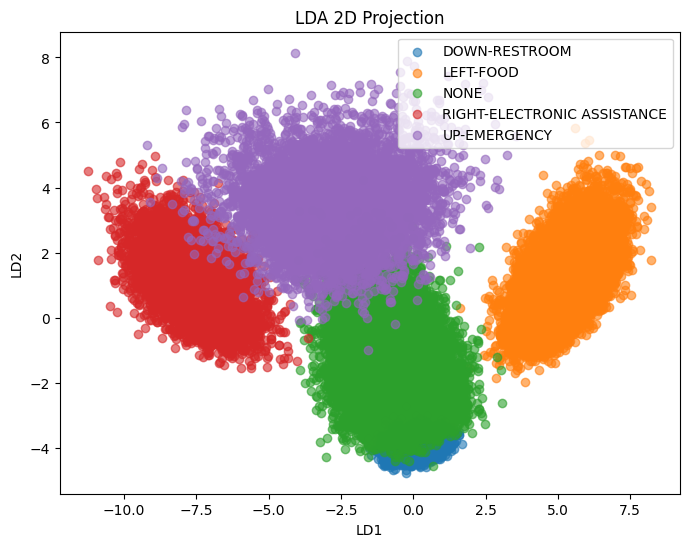

In [ ]:
# =====================================================
# FINAL LDA + RANDOM FOREST (HIGH ACCURACY VERSION)
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# =====================================================
# 1. LOAD DATASET
# =====================================================
df = pd.read_excel("mpu6050_dataset_imbalanced.xlsx")

print("Dataset Shape:", df.shape)

# =====================================================
# 2. FEATURE ENGINEERING (🔥 BOOST ACCURACY)
# =====================================================
df['acc_mag'] = np.sqrt(df['ax']**2 + df['ay']**2 + df['az']**2)
df['gyro_mag'] = np.sqrt(df['gx']**2 + df['gy']**2 + df['gz']**2)

# =====================================================
# 3. FEATURES & LABEL
# =====================================================
X = df[['ax','ay','az','gx','gy','gz','acc_mag','gyro_mag']]
y = df['label']

# =====================================================
# 4. SCALING
# =====================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =====================================================
# 5. LDA (6D → 2D)
# =====================================================
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

# =====================================================
# 6. SPLIT
# =====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_lda, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

# =====================================================
# 7. RANDOM FOREST MODEL (🔥 HIGH ACCURACY)
# =====================================================
model = RandomForestClassifier(
    n_estimators=300,        # more trees
    max_depth=None,          # full learning
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42
)

model.fit(X_train, y_train)

# =====================================================
# 8. K-FOLD VALIDATION (IMPORTANT)
# =====================================================
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(model, X_lda, y, cv=kfold)

print("\nK-FOLD MEAN ACC:", scores.mean())
print("K-FOLD STD:", scores.std())

# =====================================================
# 9. PREDICTION
# =====================================================
y_pred = model.predict(X_test)

# =====================================================
# 10. ACCURACY
# =====================================================
accuracy = accuracy_score(y_test, y_pred)
print("\nACCURACY:", accuracy)

# =====================================================
# 11. CLASSIFICATION REPORT
# =====================================================
print("\nCLASSIFICATION REPORT:\n")
print(classification_report(y_test, y_pred))

# =====================================================
# 12. CONFUSION MATRIX
# =====================================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =====================================================
# 13. SENSITIVITY & SPECIFICITY
# =====================================================
print("\nSENSITIVITY & SPECIFICITY:\n")

total = cm.sum()

for i, label in enumerate(model.classes_):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = total - (TP + FP + FN)

    sensitivity = TP / (TP + FN) if (TP + FN) != 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0

    print(f"{label}:")
    print("  Sensitivity:", round(sensitivity, 3))
    print("  Specificity:", round(specificity, 3))

# =====================================================
# 14. ROC AUC
# =====================================================
y_test_bin = label_binarize(y_test, classes=np.unique(y))
y_score = model.predict_proba(X_test)

auc = roc_auc_score(y_test_bin, y_score, multi_class='ovr')
print("\nROC AUC:", auc)

# =====================================================
# 15. LDA VISUALIZATION
# =====================================================
plt.figure(figsize=(8,6))

for label in np.unique(y):
    plt.scatter(
        X_lda[y == label, 0],
        X_lda[y == label, 1],
        label=label,
        alpha=0.6
    )

plt.legend()
plt.title("LDA 2D Projection")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.show()

Dataset Shape: (52957, 7)

K-FOLD MEAN ACC: 0.9807013435407628
K-FOLD STD: 0.0016280351464436143

ACCURACY: 0.9818731117824774

CLASSIFICATION REPORT:

                             precision    recall  f1-score   support

              DOWN-RESTROOM       0.94      0.96      0.95      1500
                  LEFT-FOOD       1.00      1.00      1.00      5018
                       NONE       0.98      0.97      0.97      5170
RIGHT-ELECTRONIC ASSISTANCE       0.99      0.99      0.99      2400
               UP-EMERGENCY       0.95      0.97      0.96      1800

                   accuracy                           0.98     15888
                  macro avg       0.97      0.98      0.98     15888
               weighted avg       0.98      0.98      0.98     15888



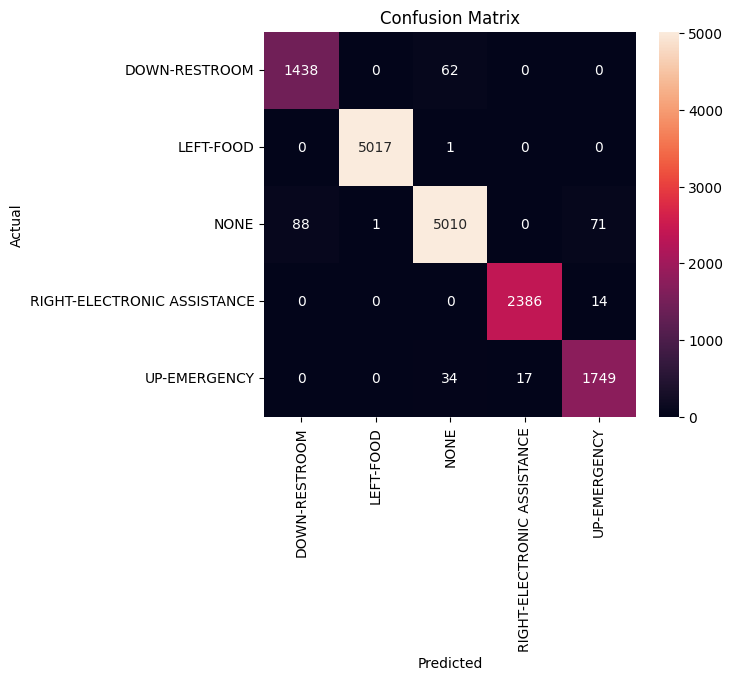


SENSITIVITY & SPECIFICITY:

DOWN-RESTROOM:
  Sensitivity: 0.959
  Specificity: 0.994
LEFT-FOOD:
  Sensitivity: 1.0
  Specificity: 1.0
NONE:
  Sensitivity: 0.969
  Specificity: 0.991
RIGHT-ELECTRONIC ASSISTANCE:
  Sensitivity: 0.994
  Specificity: 0.999
UP-EMERGENCY:
  Sensitivity: 0.972
  Specificity: 0.994

ROC AUC: 0.998667388387817


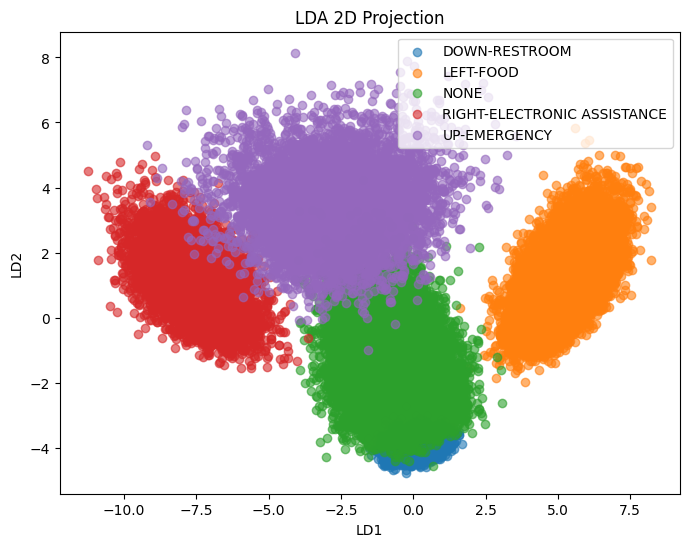

In [ ]:
# =====================================================
# FINAL LDA + RANDOM FOREST (HIGH ACCURACY VERSION)
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# =====================================================
# 1. LOAD DATASET
# =====================================================
df = pd.read_excel("mpu6050_dataset_imbalanced.xlsx")

print("Dataset Shape:", df.shape)

# =====================================================
# 2. FEATURE ENGINEERING (🔥 BOOST ACCURACY)
# =====================================================
df['acc_mag'] = np.sqrt(df['ax']**2 + df['ay']**2 + df['az']**2)
df['gyro_mag'] = np.sqrt(df['gx']**2 + df['gy']**2 + df['gz']**2)

# =====================================================
# 3. FEATURES & LABEL
# =====================================================
X = df[['ax','ay','az','gx','gy','gz','acc_mag','gyro_mag']]
y = df['label']

# =====================================================
# 4. SCALING
# =====================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =====================================================
# 5. LDA (6D → 2D)
# =====================================================
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

# =====================================================
# 6. SPLIT
# =====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_lda, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# =====================================================
# 7. RANDOM FOREST MODEL (🔥 HIGH ACCURACY)
# =====================================================
model = RandomForestClassifier(
    n_estimators=300,        # more trees
    max_depth=None,          # full learning
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42
)

model.fit(X_train, y_train)

# =====================================================
# 8. K-FOLD VALIDATION (IMPORTANT)
# =====================================================
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(model, X_lda, y, cv=kfold)

print("\nK-FOLD MEAN ACC:", scores.mean())
print("K-FOLD STD:", scores.std())

# =====================================================
# 9. PREDICTION
# =====================================================
y_pred = model.predict(X_test)

# =====================================================
# 10. ACCURACY
# =====================================================
accuracy = accuracy_score(y_test, y_pred)
print("\nACCURACY:", accuracy)

# =====================================================
# 11. CLASSIFICATION REPORT
# =====================================================
print("\nCLASSIFICATION REPORT:\n")
print(classification_report(y_test, y_pred))

# =====================================================
# 12. CONFUSION MATRIX
# =====================================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =====================================================
# 13. SENSITIVITY & SPECIFICITY
# =====================================================
print("\nSENSITIVITY & SPECIFICITY:\n")

total = cm.sum()

for i, label in enumerate(model.classes_):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = total - (TP + FP + FN)

    sensitivity = TP / (TP + FN) if (TP + FN) != 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0

    print(f"{label}:")
    print("  Sensitivity:", round(sensitivity, 3))
    print("  Specificity:", round(specificity, 3))

# =====================================================
# 14. ROC AUC
# =====================================================
y_test_bin = label_binarize(y_test, classes=np.unique(y))
y_score = model.predict_proba(X_test)

auc = roc_auc_score(y_test_bin, y_score, multi_class='ovr')
print("\nROC AUC:", auc)

# =====================================================
# 15. LDA VISUALIZATION
# =====================================================
plt.figure(figsize=(8,6))

for label in np.unique(y):
    plt.scatter(
        X_lda[y == label, 0],
        X_lda[y == label, 1],
        label=label,
        alpha=0.6
    )

plt.legend()
plt.title("LDA 2D Projection")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.show()

Dataset Shape: (52957, 7)

K-FOLD MEAN ACC: 0.9807013435407628
K-FOLD STD: 0.0016280351464436143

ACCURACY: 0.9807401812688822

CLASSIFICATION REPORT:

                             precision    recall  f1-score   support

              DOWN-RESTROOM       0.94      0.95      0.94      1000
                  LEFT-FOOD       1.00      1.00      1.00      3345
                       NONE       0.98      0.97      0.97      3447
RIGHT-ELECTRONIC ASSISTANCE       0.99      0.99      0.99      1600
               UP-EMERGENCY       0.95      0.97      0.96      1200

                   accuracy                           0.98     10592
                  macro avg       0.97      0.98      0.97     10592
               weighted avg       0.98      0.98      0.98     10592



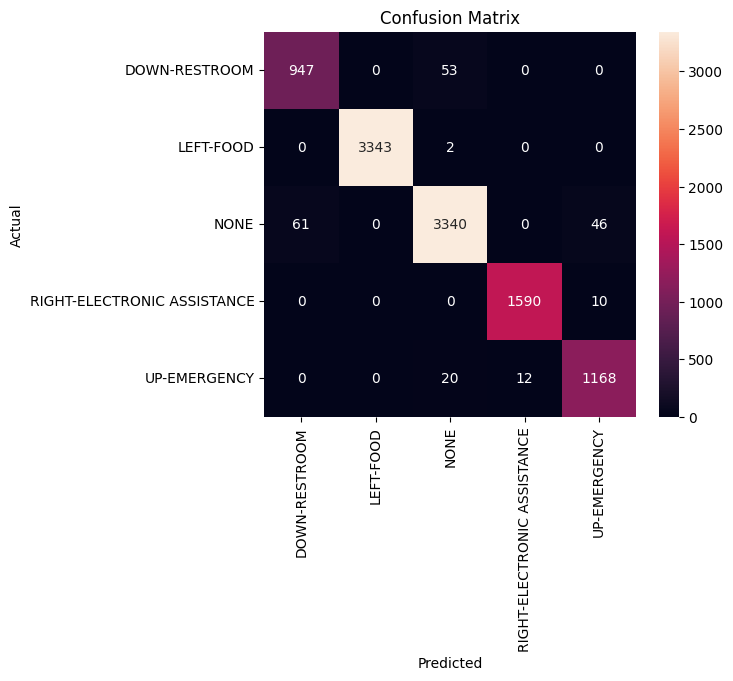


SENSITIVITY & SPECIFICITY:

DOWN-RESTROOM:
  Sensitivity: 0.947
  Specificity: 0.994
LEFT-FOOD:
  Sensitivity: 0.999
  Specificity: 1.0
NONE:
  Sensitivity: 0.969
  Specificity: 0.99
RIGHT-ELECTRONIC ASSISTANCE:
  Sensitivity: 0.994
  Specificity: 0.999
UP-EMERGENCY:
  Sensitivity: 0.973
  Specificity: 0.994

ROC AUC: 0.9981546265047678


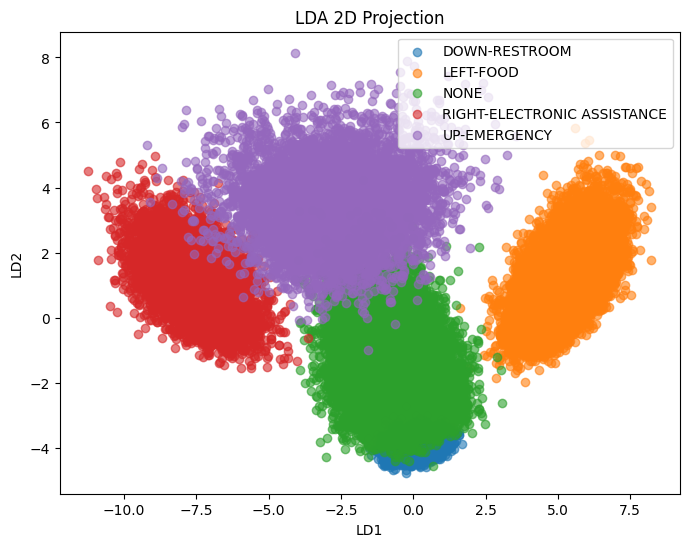

In [ ]:
# =====================================================
# FINAL LDA + RANDOM FOREST (HIGH ACCURACY VERSION)
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# =====================================================
# 1. LOAD DATASET
# =====================================================
df = pd.read_excel("mpu6050_dataset_imbalanced.xlsx")

print("Dataset Shape:", df.shape)

# =====================================================
# 2. FEATURE ENGINEERING (🔥 BOOST ACCURACY)
# =====================================================
df['acc_mag'] = np.sqrt(df['ax']**2 + df['ay']**2 + df['az']**2)
df['gyro_mag'] = np.sqrt(df['gx']**2 + df['gy']**2 + df['gz']**2)

# =====================================================
# 3. FEATURES & LABEL
# =====================================================
X = df[['ax','ay','az','gx','gy','gz','acc_mag','gyro_mag']]
y = df['label']

# =====================================================
# 4. SCALING
# =====================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =====================================================
# 5. LDA (6D → 2D)
# =====================================================
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

# =====================================================
# 6. SPLIT
# =====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_lda, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# =====================================================
# 7. RANDOM FOREST MODEL (🔥 HIGH ACCURACY)
# =====================================================
model = RandomForestClassifier(
    n_estimators=300,        # more trees
    max_depth=None,          # full learning
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42
)

model.fit(X_train, y_train)

# =====================================================
# 8. K-FOLD VALIDATION (IMPORTANT)
# =====================================================
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(model, X_lda, y, cv=kfold)

print("\nK-FOLD MEAN ACC:", scores.mean())
print("K-FOLD STD:", scores.std())

# =====================================================
# 9. PREDICTION
# =====================================================
y_pred = model.predict(X_test)

# =====================================================
# 10. ACCURACY
# =====================================================
accuracy = accuracy_score(y_test, y_pred)
print("\nACCURACY:", accuracy)

# =====================================================
# 11. CLASSIFICATION REPORT
# =====================================================
print("\nCLASSIFICATION REPORT:\n")
print(classification_report(y_test, y_pred))

# =====================================================
# 12. CONFUSION MATRIX
# =====================================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =====================================================
# 13. SENSITIVITY & SPECIFICITY
# =====================================================
print("\nSENSITIVITY & SPECIFICITY:\n")

total = cm.sum()

for i, label in enumerate(model.classes_):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = total - (TP + FP + FN)

    sensitivity = TP / (TP + FN) if (TP + FN) != 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0

    print(f"{label}:")
    print("  Sensitivity:", round(sensitivity, 3))
    print("  Specificity:", round(specificity, 3))

# =====================================================
# 14. ROC AUC
# =====================================================
y_test_bin = label_binarize(y_test, classes=np.unique(y))
y_score = model.predict_proba(X_test)

auc = roc_auc_score(y_test_bin, y_score, multi_class='ovr')
print("\nROC AUC:", auc)

# =====================================================
# 15. LDA VISUALIZATION
# =====================================================
plt.figure(figsize=(8,6))

for label in np.unique(y):
    plt.scatter(
        X_lda[y == label, 0],
        X_lda[y == label, 1],
        label=label,
        alpha=0.6
    )

plt.legend()
plt.title("LDA 2D Projection")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.show()

Dataset Shape: (52957, 7)

K-FOLD MEAN ACC: 0.9807013435407628
K-FOLD STD: 0.0016280351464436143

ACCURACY: 0.976963746223565

CLASSIFICATION REPORT:

                             precision    recall  f1-score   support

              DOWN-RESTROOM       0.93      0.94      0.93       500
                  LEFT-FOOD       1.00      1.00      1.00      1673
                       NONE       0.98      0.96      0.97      1723
RIGHT-ELECTRONIC ASSISTANCE       0.99      1.00      0.99       800
               UP-EMERGENCY       0.94      0.97      0.96       600

                   accuracy                           0.98      5296
                  macro avg       0.97      0.97      0.97      5296
               weighted avg       0.98      0.98      0.98      5296



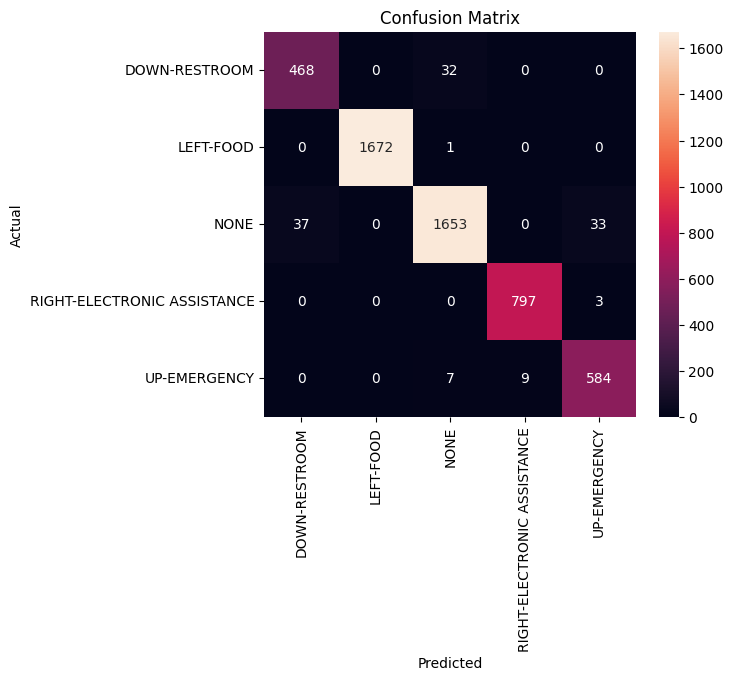


SENSITIVITY & SPECIFICITY:

DOWN-RESTROOM:
  Sensitivity: 0.936
  Specificity: 0.992
LEFT-FOOD:
  Sensitivity: 0.999
  Specificity: 1.0
NONE:
  Sensitivity: 0.959
  Specificity: 0.989
RIGHT-ELECTRONIC ASSISTANCE:
  Sensitivity: 0.996
  Specificity: 0.998
UP-EMERGENCY:
  Sensitivity: 0.973
  Specificity: 0.992

ROC AUC: 0.9969619343959206


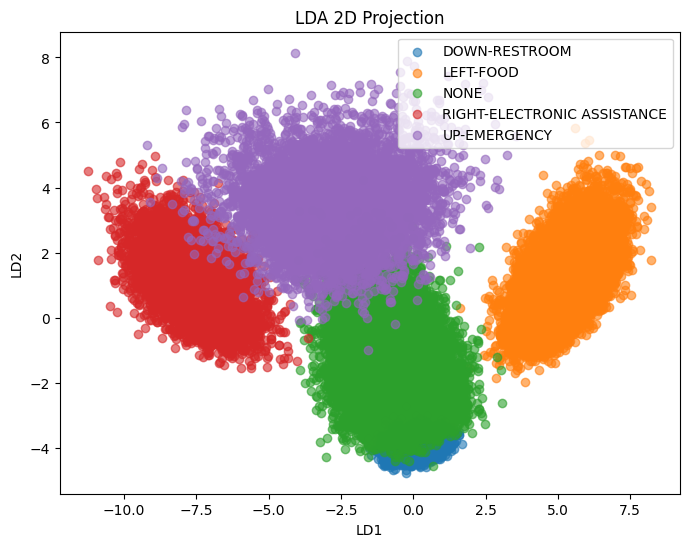

In [ ]:
# =====================================================
# FINAL LDA + RANDOM FOREST (HIGH ACCURACY VERSION)
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# =====================================================
# 1. LOAD DATASET
# =====================================================
df = pd.read_excel("mpu6050_dataset_imbalanced.xlsx")

print("Dataset Shape:", df.shape)

# =====================================================
# 2. FEATURE ENGINEERING (🔥 BOOST ACCURACY)
# =====================================================
df['acc_mag'] = np.sqrt(df['ax']**2 + df['ay']**2 + df['az']**2)
df['gyro_mag'] = np.sqrt(df['gx']**2 + df['gy']**2 + df['gz']**2)

# =====================================================
# 3. FEATURES & LABEL
# =====================================================
X = df[['ax','ay','az','gx','gy','gz','acc_mag','gyro_mag']]
y = df['label']

# =====================================================
# 4. SCALING
# =====================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =====================================================
# 5. LDA (6D → 2D)
# =====================================================
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

# =====================================================
# 6. SPLIT
# =====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_lda, y,
    test_size=0.10,
    stratify=y,
    random_state=42
)

# =====================================================
# 7. RANDOM FOREST MODEL (🔥 HIGH ACCURACY)
# =====================================================
model = RandomForestClassifier(
    n_estimators=300,        # more trees
    max_depth=None,          # full learning
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42
)

model.fit(X_train, y_train)

# =====================================================
# 8. K-FOLD VALIDATION (IMPORTANT)
# =====================================================
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(model, X_lda, y, cv=kfold)

print("\nK-FOLD MEAN ACC:", scores.mean())
print("K-FOLD STD:", scores.std())

# =====================================================
# 9. PREDICTION
# =====================================================
y_pred = model.predict(X_test)

# =====================================================
# 10. ACCURACY
# =====================================================
accuracy = accuracy_score(y_test, y_pred)
print("\nACCURACY:", accuracy)

# =====================================================
# 11. CLASSIFICATION REPORT
# =====================================================
print("\nCLASSIFICATION REPORT:\n")
print(classification_report(y_test, y_pred))

# =====================================================
# 12. CONFUSION MATRIX
# =====================================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =====================================================
# 13. SENSITIVITY & SPECIFICITY
# =====================================================
print("\nSENSITIVITY & SPECIFICITY:\n")

total = cm.sum()

for i, label in enumerate(model.classes_):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = total - (TP + FP + FN)

    sensitivity = TP / (TP + FN) if (TP + FN) != 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0

    print(f"{label}:")
    print("  Sensitivity:", round(sensitivity, 3))
    print("  Specificity:", round(specificity, 3))

# =====================================================
# 14. ROC AUC
# =====================================================
y_test_bin = label_binarize(y_test, classes=np.unique(y))
y_score = model.predict_proba(X_test)

auc = roc_auc_score(y_test_bin, y_score, multi_class='ovr')
print("\nROC AUC:", auc)

# =====================================================
# 15. LDA VISUALIZATION
# =====================================================
plt.figure(figsize=(8,6))

for label in np.unique(y):
    plt.scatter(
        X_lda[y == label, 0],
        X_lda[y == label, 1],
        label=label,
        alpha=0.6
    )

plt.legend()
plt.title("LDA 2D Projection")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.show()